In [2]:
%load_ext autoreload

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import List, Union, Tuple
import os
import pickle
import traceback

import patchcore
from common import FaissNN, NetworkFeatureAggregator
import sampler


class CrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=8, dropout=0.0):
        super(CrossAttention, self).__init__()
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, dropout, batch_first=True)
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, x_view1, x_view2):
        if not isinstance(x_view1, torch.Tensor):
            raise TypeError(f"Expected x_view1 to be a tensor, got {type(x_view1)}")
        if not isinstance(x_view2, torch.Tensor):
            raise TypeError(f"Expected x_view2 to be a tensor, got {type(x_view2)}")
            
        x_view1_norm = self.layer_norm1(x_view1)
        x_view2_norm = self.layer_norm1(x_view2)
        
        attn_output1, _ = self.mha(x_view1_norm, x_view2_norm, x_view2_norm)
        out1 = x_view1 + attn_output1
        
        attn_output2, _ = self.mha(x_view2_norm, x_view1_norm, x_view1_norm)
        out2 = x_view2 + attn_output2

        combined = (out1 + out2) / 2
        combined_norm = self.layer_norm2(combined)
        ffn_output = self.ffn(combined_norm)
        
        return combined + ffn_output


class MultiViewFeatureFusion:
    def __init__(self, fusion_method='cross_attention', embed_dim=1024, num_heads=8):
        self.fusion_method = fusion_method
        self.embed_dim = embed_dim
        
        if fusion_method == 'cross_attention':
            self.cross_attention = CrossAttention(embed_dim, num_heads)
            
    def fuse_features(self, features_view1, features_view2):
        """Fuse features from two views"""
        if self.fusion_method == 'concatenate':
            return np.concatenate([features_view1, features_view2], axis=1)
        
        elif self.fusion_method == 'cross_attention':

            if isinstance(features_view1, list) and isinstance(features_view1[0], np.ndarray):

                features_view1 = torch.tensor(np.array(features_view1), dtype=torch.float32)
                features_view2 = torch.tensor(np.array(features_view2), dtype=torch.float32)

            elif isinstance(features_view1, np.ndarray):
                features_view1 = torch.from_numpy(features_view1).float()
                features_view2 = torch.from_numpy(features_view2).float()
  
            elif isinstance(features_view1, list) and isinstance(features_view1[0], torch.Tensor):
                features_view1 = torch.stack(features_view1)
                features_view2 = torch.stack(features_view2)

            fused = self.cross_attention(features_view1, features_view2)
 
            if isinstance(features_view1, np.ndarray) or (isinstance(features_view1, list) and 
                                                         isinstance(features_view1[0], np.ndarray)):
                fused = fused.detach().cpu().numpy()
                
            return fused

# adapted from  https://github.com/amazon-science/patchcore-inspection/blob/main/src/patchcore/patchcore.py
class PatchCoreMV(nn.Module):
    """PatchCore multi-view implementation with cross-attention"""
    
    def __init__(self, device):
        super(PatchCoreMV, self).__init__()
        self.device = device
        
    def load(
        self,
        backbone,
        layers_to_extract_from,
        device,
        input_shape,
        pretrain_embed_dimension,
        target_embed_dimension,
        patchsize=3,
        patchstride=1,
        anomaly_score_num_nn=1,
        featuresampler=sampler.IdentitySampler(),
        nn_method=FaissNN(True, 4),
        fusion_method='cross_attention',
        **kwargs,
    ):
        self.backbone = backbone.to(device)
        self.layers_to_extract_from = layers_to_extract_from
        self.input_shape = input_shape
        self.device = device
        self.patch_maker = patchcore.PatchMaker(patchsize, stride=patchstride)
        
        self.forward_modules = torch.nn.ModuleDict({})
        
        feature_aggregator = NetworkFeatureAggregator(
            self.backbone, self.layers_to_extract_from, self.device
        )
        feature_dimensions = feature_aggregator.feature_dimensions(input_shape)
        self.forward_modules["feature_aggregator"] = feature_aggregator
        
        preprocessing = patchcore.common.Preprocessing(
            feature_dimensions, pretrain_embed_dimension
        )
        self.forward_modules["preprocessing"] = preprocessing
        
     
        self.target_embed_dimension = target_embed_dimension
        preadapt_aggregator = patchcore.common.Aggregator(
            target_dim=target_embed_dimension
        )
        _ = preadapt_aggregator.to(self.device)
        self.forward_modules["preadapt_aggregator"] = preadapt_aggregator

        self.feature_fusion = MultiViewFeatureFusion(
            fusion_method=fusion_method, 
            embed_dim=target_embed_dimension
        )
        
    
        self.anomaly_scorer = patchcore.common.NearestNeighbourScorer(
            n_nearest_neighbours=anomaly_score_num_nn, nn_method=nn_method
        )

        self.anomaly_segmentor = patchcore.common.RescaleSegmentor(
            device=self.device, target_size=input_shape[-2:]
        )
        
        self.featuresampler = featuresampler
        
    def embed_view(self, images, detach=True, provide_patch_shapes=False):
        """Extract features from a single view"""
        def _detach(features):
            if detach:
                return [x.detach().cpu().numpy() for x in features]
            return features
        
        _ = self.forward_modules["feature_aggregator"].eval()
        with torch.no_grad():
            features = self.forward_modules["feature_aggregator"](images)
            
        features = [features[layer] for layer in self.layers_to_extract_from]
        
        features = [
            self.patch_maker.patchify(x, return_spatial_info=True) for x in features
        ]
        patch_shapes = [x[1] for x in features]
        features = [x[0] for x in features]
        ref_num_patches = patch_shapes[0]
        

        for i in range(1, len(features)):
            _features = features[i]
            patch_dims = patch_shapes[i]
            
            _features = _features.reshape(
                _features.shape[0], patch_dims[0], patch_dims[1], *_features.shape[2:]
            )
            _features = _features.permute(0, -3, -2, -1, 1, 2)
            perm_base_shape = _features.shape
            _features = _features.reshape(-1, *_features.shape[-2:])
            _features = F.interpolate(
                _features.unsqueeze(1),
                size=(ref_num_patches[0], ref_num_patches[1]),
                mode="bilinear",
                align_corners=False,
            )
            _features = _features.squeeze(1)
            _features = _features.reshape(
                *perm_base_shape[:-2], ref_num_patches[0], ref_num_patches[1]
            )
            _features = _features.permute(0, -2, -1, 1, 2, 3)
            _features = _features.reshape(len(_features), -1, *_features.shape[-3:])
            features[i] = _features
        
        features = [x.reshape(-1, *x.shape[-3:]) for x in features]
        
       
        features = self.forward_modules["preprocessing"](features)
        features = self.forward_modules["preadapt_aggregator"](features)
        
        if provide_patch_shapes:
            return _detach(features), patch_shapes
        return _detach(features)
    
    def fit(self, training_data_loader):
        """Train the model with multi-view data"""

        _ = self.forward_modules.eval()
        
        features_views = []
        print("Starting feature extraction...")
        total_batches = len(training_data_loader)
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(training_data_loader):
                print(f"Processing batch {batch_idx+1}/{total_batches}")
                
                print(f"  Extracting features from view 1...")
                view1 = batch["view1"].to(torch.float).to(self.device)
                features_view1 = self.embed_view(view1)
                print(f"  View 1 features extracted: {len(features_view1)} patches")
        
                print(f"  Extracting features from view 2...")
                view2 = batch["view2"].to(torch.float).to(self.device)
                features_view2 = self.embed_view(view2)
                print(f"  View 2 features extracted: {len(features_view2)} patches")
                
                print(f"  Fusing features...")
                fused_features = self.feature_fusion.fuse_features(features_view1, features_view2)
                print(f"  Features fused successfully, shape: {fused_features.shape if hasattr(fused_features, 'shape') else 'list of length ' + str(len(fused_features))}")
                
                features_views.append(fused_features)
                print(f"  Batch {batch_idx+1} completed")
        
        print("All batches processed, concatenating features...")

        if isinstance(features_views[0], np.ndarray):
            features = np.concatenate(features_views, axis=0)
            print(f"Features concatenated, shape: {features.shape}")
        else:
            if isinstance(features_views[0], torch.Tensor):
                features = torch.cat(features_views, dim=0).detach().cpu().numpy()
                print(f"Tensor features concatenated and converted to numpy, shape: {features.shape}")
            else:
  
                try:
                    features = np.concatenate(features_views, axis=0)
                    print(f"Features concatenated (special case), shape: {features.shape}")
                except:
                    print("WARNING: Could not concatenate features, trying alternative approach")
                    features = np.array([item for sublist in features_views for item in sublist])
                    print(f"Features converted and concatenated, shape: {features.shape}")
        
        print("Applying feature sampling...")
        try:
            features = self.featuresampler.run(features)
            print(f"Feature sampling completed, final shape: {features.shape}")
        except Exception as e:
            print(f"ERROR during feature sampling: {str(e)}")
  
            traceback.print_exc()
        print("Fitting anomaly scorer...")
        try:
            self.anomaly_scorer.fit(detection_features=[features])
            print("Anomaly scorer fitted successfully")
        except Exception as e:
            print(f"ERROR during anomaly scorer fitting: {str(e)}")
            traceback.print_exc()
        
        print("Training completed successfully")
    
    def predict(self, data_loader):
        """Perform anomaly detection on test data"""
 
        
        print("Starting prediction process...")
        _ = self.forward_modules.eval()
        
        scores = []
        masks = []
        labels_gt = []
        masks_gt = []
        
        print(f"Processing {len(data_loader)} test batches...")
        for batch_idx, batch in enumerate(data_loader):
            print(f"Processing test batch {batch_idx+1}/{len(data_loader)}")
            
          
            if "is_anomaly" in batch:
                print(f"  Ground truth available, adding {len(batch['is_anomaly'])} labels")
                labels_gt.extend(batch["is_anomaly"].numpy().tolist())
            if "mask" in batch:
                print(f"  Masks available, adding {len(batch['mask'])} masks")
                masks_gt.extend(batch["mask"].numpy().tolist())
            
          
            print("  Processing views...")
            view1 = batch["view1"].to(torch.float).to(self.device)
            view2 = batch["view2"].to(torch.float).to(self.device)
            
      
            print("  Predicting anomaly scores and masks...")
            try:
                _scores, _masks = self._predict_batch(view1, view2)
                print(f"  Prediction successful: got {len(_scores)} scores and {len(_masks)} masks")
                
                for score, mask in zip(_scores, _masks):
                    scores.append(score)
                    masks.append(mask)
            except Exception as e:
                print(f"  ERROR during prediction: {str(e)}")

                traceback.print_exc()
                
            print(f"  Batch {batch_idx+1} completed")
        
        print(f"Prediction complete. Processed {len(scores)} samples.")
        return scores, masks, labels_gt, masks_gt
        
    def _predict_batch(self, view1, view2):
        print("    Starting batch prediction...")
        batch_size = view1.shape[0]
        print(f"    Batch size: {batch_size}")
        
        with torch.no_grad():
            print("    Extracting features from view 1...")
            features_view1, patch_shapes_view1 = self.embed_view(view1, provide_patch_shapes=True)
            print(f"    View 1 features extracted: {len(features_view1) if isinstance(features_view1, list) else features_view1.shape} patches")
            
            print("    Extracting features from view 2...")
            features_view2, patch_shapes_view2 = self.embed_view(view2, provide_patch_shapes=True)
            print(f"    View 2 features extracted: {len(features_view2) if isinstance(features_view2, list) else features_view2.shape} patches")
            print("    Fusing features...")
            fused_features = self.feature_fusion.fuse_features(features_view1, features_view2)
            print(f"    Features fused successfully")
            patch_shapes = patch_shapes_view1
            print("    Computing anomaly scores...")
            patch_scores = image_scores = self.anomaly_scorer.predict([fused_features])[0]
            print(f"    Anomaly scores computed, shape: {patch_scores.shape if hasattr(patch_scores, 'shape') else 'unknown'}")
            
            print("    Processing image-level scores...")
            image_scores = self.patch_maker.unpatch_scores(
                image_scores, batchsize=batch_size
            )
            image_scores = image_scores.reshape(*image_scores.shape[:2], -1)
            image_scores = self.patch_maker.score(image_scores)
            print(f"    Image scores processed, count: {len(image_scores)}")
  
            print("    Creating segmentation masks...")
            patch_scores = self.patch_maker.unpatch_scores(
                patch_scores, batchsize=batch_size
            )
            scales = patch_shapes[0]
            patch_scores = patch_scores.reshape(batch_size, scales[0], scales[1])
            
            print("    Generating final masks...")
            masks = self.anomaly_segmentor.convert_to_segmentation(patch_scores)
            print(f"    Masks generated, count: {len(masks)}")
            
        print("    Batch prediction completed")
        return [score for score in image_scores], [mask for mask in masks]
    
    def save_to_path(self, save_path):
        """Save the model to disk"""
        os.makedirs(save_path, exist_ok=True)
        
        self.anomaly_scorer.save(save_path, save_features_separately=True)
    
        model_params = {
            "backbone.name": self.backbone.name,
            "layers_to_extract_from": self.layers_to_extract_from,
            "input_shape": self.input_shape,
            "pretrain_embed_dimension": self.forward_modules["preprocessing"].output_dim,
            "target_embed_dimension": self.target_embed_dimension,
            "patchsize": self.patch_maker.patchsize,
            "patchstride": self.patch_maker.stride,
            "anomaly_score_num_nn": self.anomaly_scorer.n_nearest_neighbours,
            "fusion_method": self.feature_fusion.fusion_method,
        }
        
        with open(os.path.join(save_path, "patchcore_mv_params.pkl"), "wb") as f:
            pickle.dump(model_params, f, pickle.HIGHEST_PROTOCOL)
    
    def load_from_path(self, load_path, device, nn_method=FaissNN(False, 4)):

        with open(os.path.join(load_path, "patchcore_mv_params.pkl"), "rb") as f:
            params = pickle.load(f)
            

        params["backbone"] = patchcore.backbones.load(params["backbone.name"])
        params["backbone"].name = params["backbone.name"]
        del params["backbone.name"]
        
        self.load(**params, device=device, nn_method=nn_method)
        self.anomaly_scorer.load(load_path)


def run_patchcore_mv(train_loader, test_loader, backbone_name="wide_resnet50_2", device="cuda"):
    """Run PatchCore Multi-View example"""
    
    device = torch.device(device if torch.cuda.is_available() else "cpu")
 
    backbone = patchcore.backbones.load(backbone_name)
    backbone.name = backbone_name

    layers_to_extract_from = ["layer2", "layer3"]

    model = PatchCoreMV(device)
    feature_sampler = sampler.ApproximateGreedyCoresetSampler(percentage=0.1, device=device)

    model.load(
        backbone=backbone,
        layers_to_extract_from=layers_to_extract_from,
        device=device,
        input_shape=(3, 224, 224),
        pretrain_embed_dimension=1024,
        target_embed_dimension=1024,
        featuresampler=feature_sampler,
        patchsize=3,
        patchstride=1,
        anomaly_score_num_nn=1,
        fusion_method="cross_attention",
    )

    print("Training PatchCore Multi-View...")
    model.fit(train_loader)
    
    print("Evaluating on test data...")
    scores, segmentations, labels, masks = model.predict(test_loader)

    return model, scores, segmentations, labels, masks

Creating dataloaders...
Initializing model for diagnosis...


c:\Users\feder\anaconda3\envs\patchcore-env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\feder\anaconda3\envs\patchcore-env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1`. You can also use `weights=Wide_ResNet50_2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Running diagnostic function...
View1 input shape: torch.Size([2, 3, 224, 224])

Feature aggregator outputs:
  Layer layer2 shape: torch.Size([2, 512, 28, 28])
  Layer layer3 shape: torch.Size([2, 1024, 14, 14])

Embed view processing:
  features_view1 is a list of length 1568
  First element type: <class 'numpy.ndarray'>
  First element shape: (1024,)

View2 input shape: torch.Size([2, 3, 224, 224])
  features_view2 is a list of length 1568
  First element type: <class 'numpy.ndarray'>
  First element shape: (1024,)

Trying feature fusion:
  Converted features to tensors with shapes: torch.Size([1568, 1024]), torch.Size([1568, 1024])
  Testing CrossAttention forward pass...
  CrossAttention successful! Output shape: torch.Size([1568, 1024])
  Testing MultiViewFeatureFusion.fuse_features...
  Fusion successful! Output tensor shape: torch.Size([1568, 1024])
  Feature fusion is working correctly!

Running PatchCore with Cross-Attention...
Training PatchCore Multi-View...
Starting feature 

Subsampling...: 100%|██████████| 23520/23520 [00:38<00:00, 616.03it/s]


Feature sampling completed, final shape: (23520, 1024)
Fitting anomaly scorer...
Anomaly scorer fitted successfully
Training completed successfully
Evaluating on test data...
Starting prediction process...
Processing 49 test batches...
Processing test batch 1/49
  Ground truth available, adding 2 labels
  Masks available, adding 2 masks
  Processing views...
  Predicting anomaly scores and masks...
    Starting batch prediction...
    Batch size: 2
    Extracting features from view 1...
    View 1 features extracted: 1568 patches
    Extracting features from view 2...
    View 2 features extracted: 1568 patches
    Fusing features...
    Features fused successfully
    Computing anomaly scores...
    Anomaly scores computed, shape: (1568,)
    Processing image-level scores...
    Image scores processed, count: 2
    Creating segmentation masks...
    Generating final masks...
    Masks generated, count: 2
    Batch prediction completed
  Prediction successful: got 2 scores and 2 masks


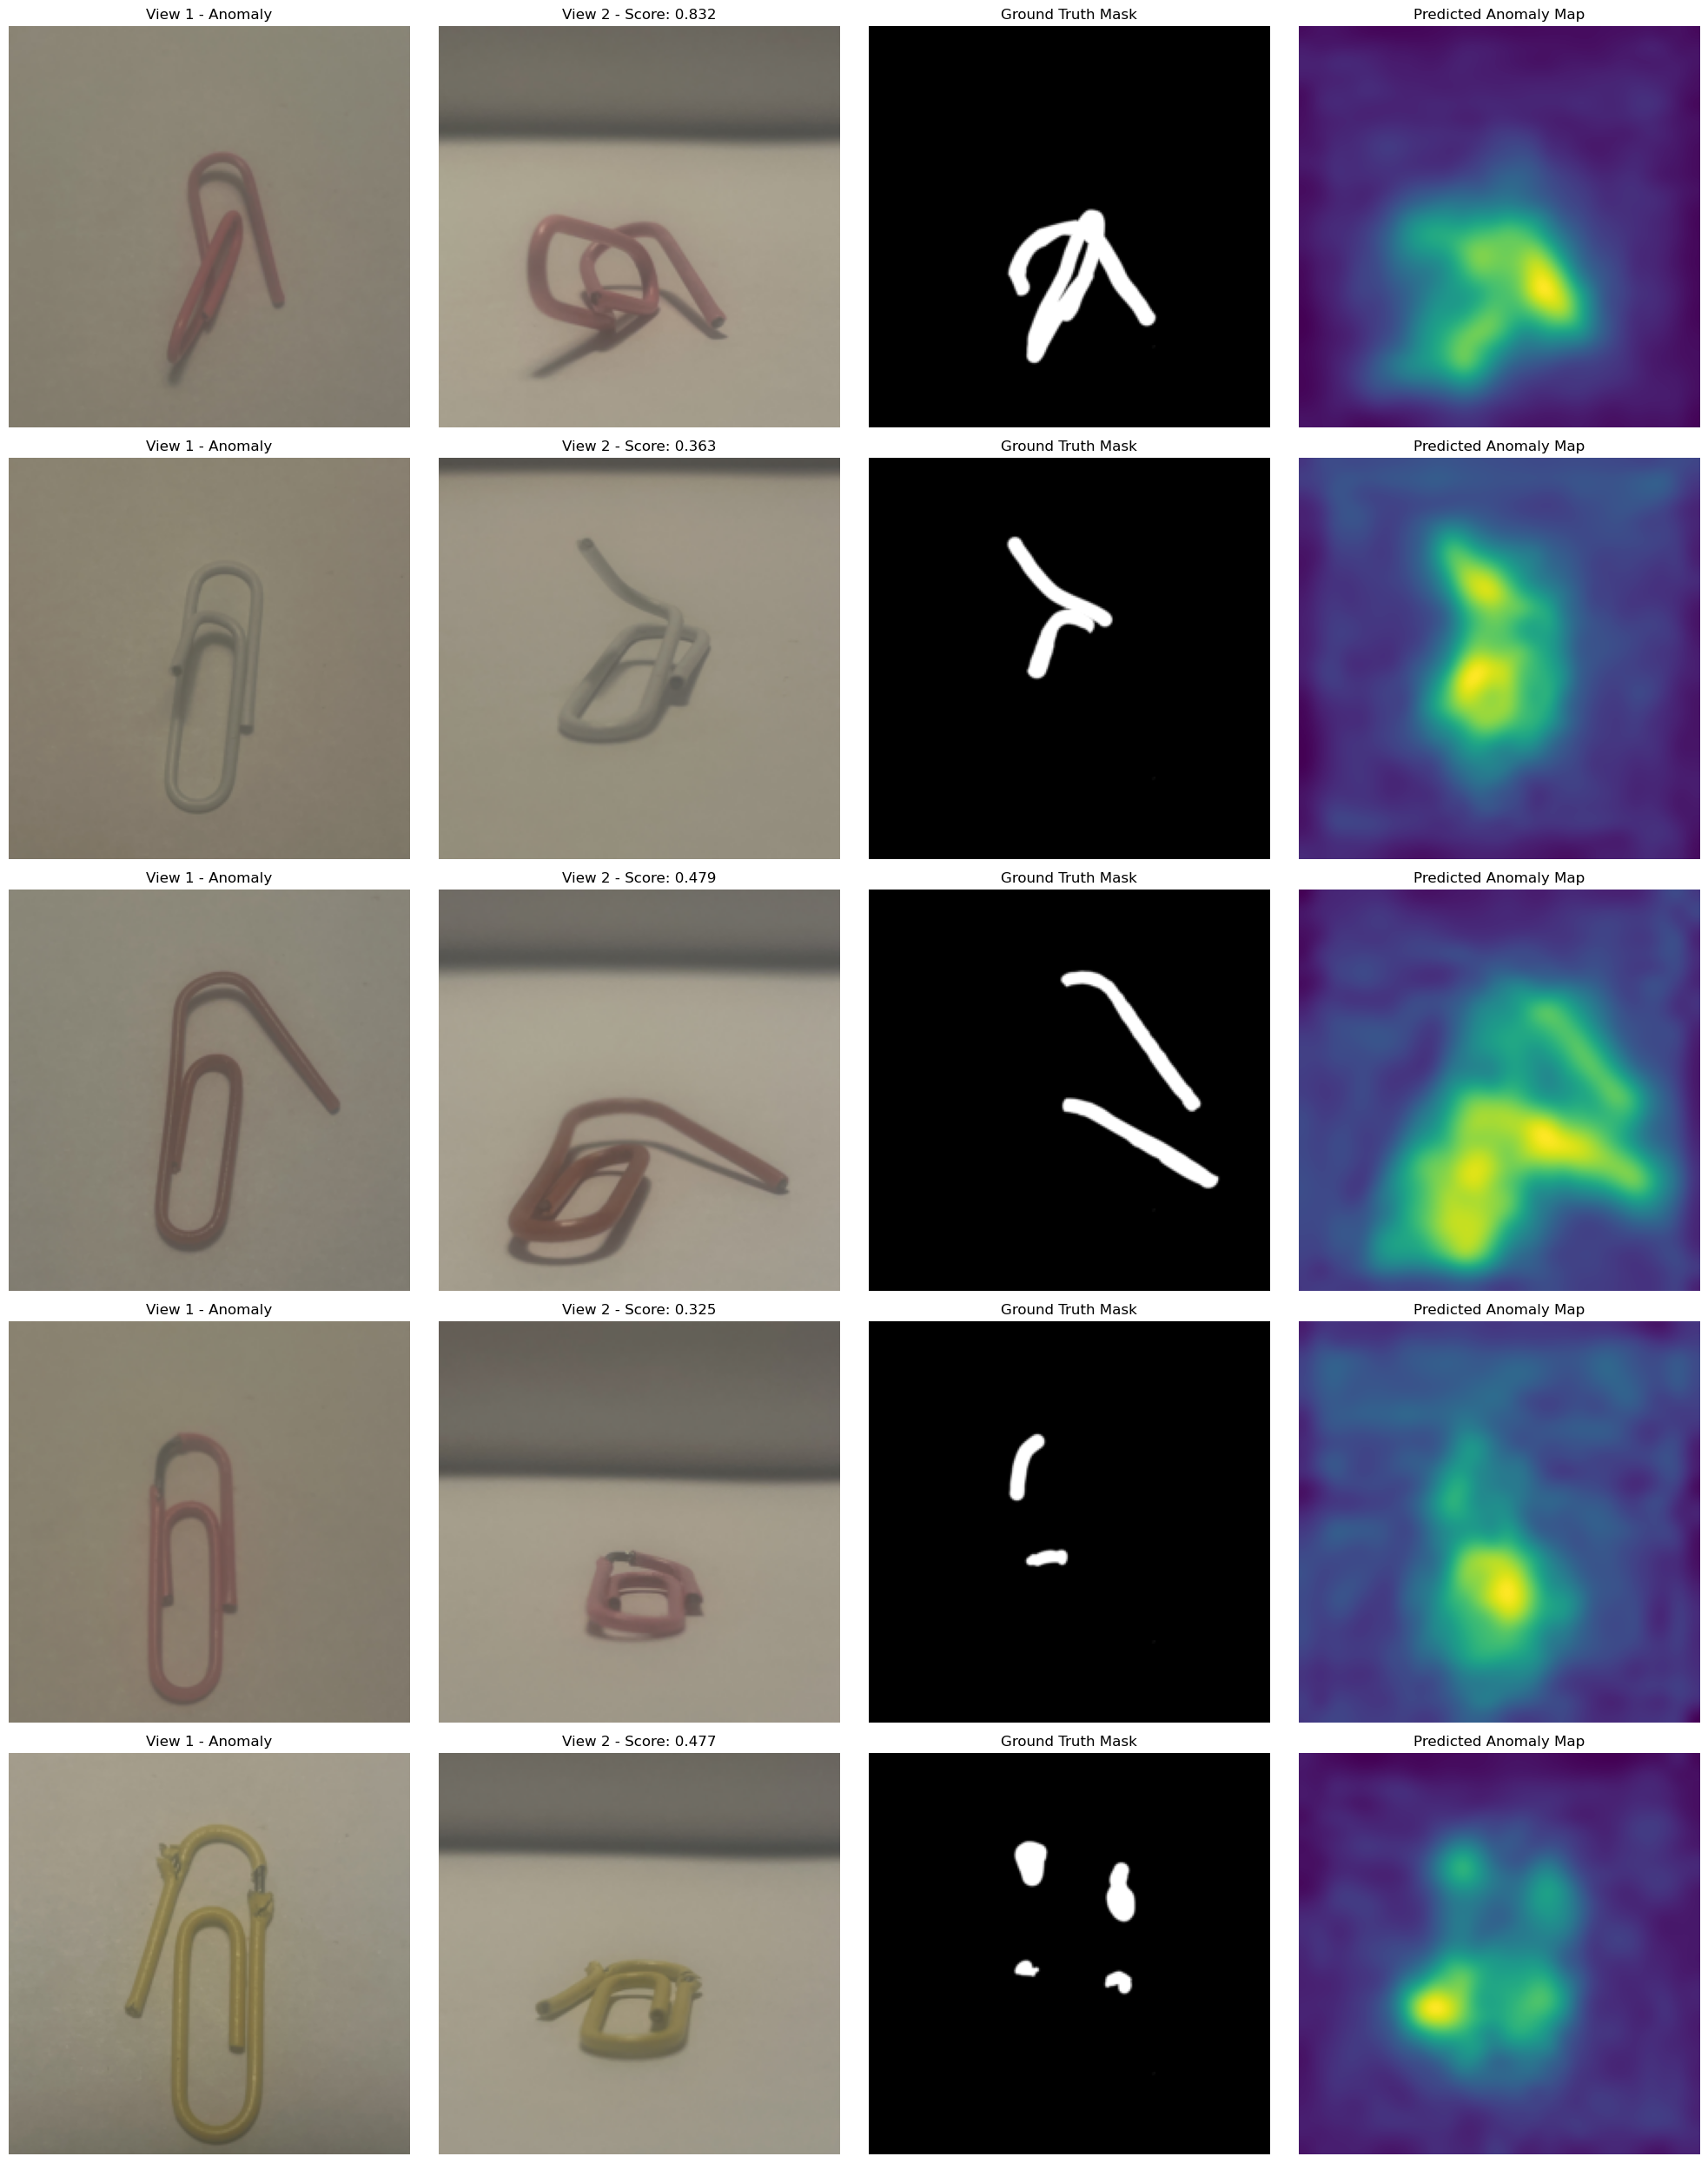

Model saved to ./patchcore_mv_model


In [ ]:

from sklearn import metrics
import matplotlib.pyplot as plt


from sampler import IdentitySampler, RandomSampler, ApproximateGreedyCoresetSampler
from common import FaissNN


def inspect_patchcore_features(model, train_loader):
    _ = model.forward_modules.eval()
    batch = next(iter(train_loader))
    view1 = batch["view1"].to(torch.float).to(model.device)
    print(f"View1 input shape: {view1.shape}")
    with torch.no_grad():
        features = model.forward_modules["feature_aggregator"](view1)
        print("\nFeature aggregator outputs:")
        for layer in model.layers_to_extract_from:
            print(f"  Layer {layer} shape: {features[layer].shape}")
            
   
        print("\nEmbed view processing:")
        features_view1 = model.embed_view(view1)
     
        if isinstance(features_view1, list):
            print(f"  features_view1 is a list of length {len(features_view1)}")
            if len(features_view1) > 0:
                print(f"  First element type: {type(features_view1[0])}")
                if isinstance(features_view1[0], np.ndarray):
                    print(f"  First element shape: {features_view1[0].shape}")
        elif isinstance(features_view1, np.ndarray):
            print(f"  features_view1 is a numpy array with shape {features_view1.shape}")
        elif isinstance(features_view1, torch.Tensor):
            print(f"  features_view1 is a torch.Tensor with shape {features_view1.shape}")
            
    # Process view 2
    view2 = batch["view2"].to(torch.float).to(model.device)
    print(f"\nView2 input shape: {view2.shape}")
 
    with torch.no_grad():
        features_view2 = model.embed_view(view2)
        
        if isinstance(features_view2, list):
            print(f"  features_view2 is a list of length {len(features_view2)}")
            if len(features_view2) > 0:
                print(f"  First element type: {type(features_view2[0])}")
                if isinstance(features_view2[0], np.ndarray):
                    print(f"  First element shape: {features_view2[0].shape}")
        elif isinstance(features_view2, np.ndarray):
            print(f"  features_view2 is a numpy array with shape {features_view2.shape}")
        elif isinstance(features_view2, torch.Tensor):
            print(f"  features_view2 is a torch.Tensor with shape {features_view2.shape}")
  
    print("\nTrying feature fusion:")
    try:
    
        if isinstance(features_view1, list) and isinstance(features_view1[0], np.ndarray):
            features_view1_tensor = torch.tensor(np.array(features_view1), dtype=torch.float32)
            features_view2_tensor = torch.tensor(np.array(features_view2), dtype=torch.float32)
            print(f"  Converted features to tensors with shapes: {features_view1_tensor.shape}, {features_view2_tensor.shape}")
        
            print("  Testing CrossAttention forward pass...")
            fused_tensor = model.feature_fusion.cross_attention(features_view1_tensor, features_view2_tensor)
            print(f"  CrossAttention successful! Output shape: {fused_tensor.shape}")

        print("  Testing MultiViewFeatureFusion.fuse_features...")
        fused_features = model.feature_fusion.fuse_features(features_view1, features_view2)
        
        if isinstance(fused_features, np.ndarray):
            print(f"  Fusion successful! Output shape: {fused_features.shape}")
        elif isinstance(fused_features, torch.Tensor):
            print(f"  Fusion successful! Output tensor shape: {fused_features.shape}")
        print("  Feature fusion is working correctly!")
    except Exception as e:
        print(f"  Error during feature fusion: {str(e)}")
        print("  Detailed traceback:")
        import traceback
        traceback.print_exc()


def get_mvtec_dataloaders(data_path, category, batch_size=2):
    """Create MVTec Multi-View dataloaders for the specified category"""

    from Multiview_dataset_crossattention import MVTecMultiViewDataset ,DatasetSplit
    
    classnames = [f"{category}_front", f"{category}_side"] 

    train_dataset = MVTecMultiViewDataset(
        source=data_path,
        classnames=classnames,
        resize=256,
        imagesize=224,
        split=DatasetSplit.TRAIN,
    )
    
    test_dataset = MVTecMultiViewDataset(
        source=data_path,
        classnames=classnames,
        resize=256,
        imagesize=224,
        split=DatasetSplit.TEST,
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
    )
    
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )
    
    return train_loader, test_loader

def calculate_metrics(gt_labels, anomaly_scores):
    """Calculate AUROC and other metrics"""
    fpr, tpr, thresholds = metrics.roc_curve(gt_labels, anomaly_scores)
    auroc = metrics.roc_auc_score(gt_labels, anomaly_scores)
    precision, recall, thresholds_pr = metrics.precision_recall_curve(gt_labels, anomaly_scores)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_threshold = thresholds_pr[np.argmax(f1_scores)]

    predictions = (np.array(anomaly_scores) >= best_threshold).astype(int)
    accuracy = metrics.accuracy_score(gt_labels, predictions)
    
    return {
        "auroc": auroc,
        "accuracy": accuracy,
        "best_threshold": best_threshold,
        "fpr": fpr,
        "tpr": tpr
    }

def visualize_results(labels, scores, segmentations, test_loader, num_samples=5):
    """Visualize some results for qualitative analysis"""
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))

    max_score = max(scores)
    min_score = min(scores)
    normalized_scores = [(s - min_score) / (max_score - min_score) for s in scores]

    anomaly_indices = [i for i, label in enumerate(labels) if label == 1]
    
    if len(anomaly_indices) < num_samples:
        sample_indices = anomaly_indices + [i for i, label in enumerate(labels) if label == 0][:num_samples-len(anomaly_indices)]
    else:
        sample_indices = anomaly_indices[:num_samples]
    

    test_iter = iter(test_loader)
    batch_map = {}
    
    for i, sample_idx in enumerate(sample_indices):

        batch_idx = sample_idx // test_loader.batch_size
        pos_in_batch = sample_idx % test_loader.batch_size
        if batch_idx not in batch_map:
            for _ in range(batch_idx + 1 - len(batch_map)):
                try:
                    batch_map[len(batch_map)] = next(test_iter)
                except StopIteration:
                    break
        
        batch = batch_map[batch_idx]
        
        view1 = batch["view1"][pos_in_batch].permute(1, 2, 0).cpu().numpy()
        view2 = batch["view2"][pos_in_batch].permute(1, 2, 0).cpu().numpy()
        mask = batch["mask"][pos_in_batch].permute(1, 2, 0).cpu().numpy()
        
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        view1 = std * view1 + mean
        view2 = std * view2 + mean
        view1 = np.clip(view1, 0, 1)
        view2 = np.clip(view2, 0, 1)
  
        pred_mask = segmentations[sample_idx]
        
        axes[i, 0].imshow(view1)
        axes[i, 0].set_title(f"View 1 - {'Anomaly' if labels[sample_idx] == 1 else 'Normal'}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(view2)
        axes[i, 1].set_title(f"View 2 - Score: {normalized_scores[sample_idx]:.3f}")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(mask[:,:,0], cmap='gray')
        axes[i, 2].set_title("Ground Truth Mask")
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(pred_mask, cmap='viridis')
        axes[i, 3].set_title("Predicted Anomaly Map")
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

def main():

    data_path = r"C:\Thesis\Data\paperclips_sorted"
    category = "paperclips"  

    print("Creating dataloaders...")
    train_loader, test_loader = get_mvtec_dataloaders(data_path, category)

    print("Initializing model for diagnosis...")
 
    backbone = patchcore.backbones.load("wideresnet50")
    backbone.name = "wideresnet50"

    layers_to_extract_from = ["layer2", "layer3"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PatchCoreMV(device)

    model.load(
        backbone=backbone,
        layers_to_extract_from=layers_to_extract_from,
        device=device,
        input_shape=(3, 224, 224),
        pretrain_embed_dimension=1024,
        target_embed_dimension=1024,
        patchsize=3,
        patchstride=1,
        anomaly_score_num_nn=1,
        fusion_method="cross_attention",
    )
    
    print("Running diagnostic function...")
    inspect_patchcore_features(model, train_loader)
 
    print("\nRunning PatchCore with Cross-Attention...")
    model, scores, segmentations, labels, masks = run_patchcore_mv(
        train_loader, 
        test_loader, 
        backbone_name="wideresnet50", 
        device="cuda"
    )
    
    print("Calculating metrics...")
    metrics_results = calculate_metrics(labels, scores)
    print(f"AUROC: {metrics_results['auroc']:.4f}")
    print(f"Accuracy: {metrics_results['accuracy']:.4f}")
    print("Visualizing results...")
    visualize_results(labels, scores, segmentations, test_loader)

    model.save_to_path("./patchcore_mv_model")
    print("Model saved to ./patchcore_mv_model")

if __name__ == "__main__":
    main()